# Aula Prática: Modelos de Classificação em Ação
Vamos assumir o papel de um Cientista de Dados de um restaurante.

**Nosso objetivo**: Criar um modelo de Inteligência Artificial capaz de prever se um cliente deixará uma "Gorjeta Generosa" (maior que 15% do valor da conta) baseado no seu perfil e no momento do consumo.

In [ ]:
# IMPORTAÇÃO DE BIBLIOTECAS


# Pandas: Biblioteca fundamental para carregar, organizar e manipular tabelas de dados (DataFrames).
# O 'as pd' é um apelido padrão para não precisarmos digitar 'pandas' toda vez.
import pandas as pd

# Matplotlib e Seaborn: Ferramentas gráficas.
# O Matplotlib é a base de desenho, e o Seaborn (sns) facilita a criação de gráficos estatísticos bonitos.
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn (sklearn): A principal biblioteca de Machine Learning em Python.
# Importamos apenas as ferramentas específicas que usaremos para economizar memória:
# - train_test_split: Função que embaralha e divide a tabela em dados de Treino (passado) e Teste (futuro).
from sklearn.model_selection import train_test_split
# - StandardScaler: Ferramenta que padroniza os números (Escalonamento), colocando todos na mesma escala.
from sklearn.preprocessing import StandardScaler

# Importação dos 5 Algoritmos de Classificação que estudamos
from sklearn.neighbors import KNeighborsClassifier      # k-NN
from sklearn.tree import DecisionTreeClassifier         # Árvore de Decisão
from sklearn.naive_bayes import GaussianNB              # Naive Bayes (Fórmula Gaussiana)
from sklearn.linear_model import LogisticRegression     # Regressão Logística
from sklearn.ensemble import RandomForestClassifier     # Random Forest (Floresta)

# Biblioteca para silenciar mensagens de aviso (warnings) em vermelho que o Python gera ao atualizar versões,
# mantendo a tela limpa e amigável para os alunos.
import warnings
warnings.filterwarnings('ignore')

##Passo 1: Importação e Transformação do Objetivo
Primeiro, vamos carregar os dados brutos. Como nosso objetivo é prever uma **categoria** (Classificação), precisamos transformar o valor **numérico** da **gorjeta** em uma resposta de "Sim" ou "Não" (**Gorjeta Generosa**).

In [ ]:
# IMPORTAÇÃO DOS DADOS

# pd.read_csv(): Função do Pandas que vai até a internet (URL), lê um arquivo de texto separado por vírgulas (CSV)
# e o transforma em uma tabela organizada nas linhas e colunas (DataFrame).
url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv'
df = pd.read_csv(url)

# Exibindo as 5 primeiras linhas para ver o resultado
display(df.head())

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [ ]:
# AJUSTANDO VARIÁVEL ALVO

# Criando uma nova coluna chamada 'porcentagem_gorjeta'.
# Ela é o resultado da divisão da coluna 'tip' (gorjeta) pela coluna 'total_bill' (conta total).
df['porcentagem_gorjeta'] = df['tip'] / df['total_bill']

# Criando a Variável Alvo (Target) chamada 'gorjeta_generosa'.
# A expressão (df['porcentagem_gorjeta'] > 0.15) retorna Verdadeiro ou Falso.
# O comando .astype(int) transforma Verdadeiro em 1 (Generosa) e Falso em 0 (Normal).
df['gorjeta_generosa'] = (df['porcentagem_gorjeta'] > 0.15).astype(int)

# display(): Função visual do Google Colab que imprime tabelas de forma bonita na tela.
# .head(): Traz apenas as 5 primeiras linhas da tabela, para não travar a tela com milhares de registros.
display(df.head())

,total_bill,tip,sex,smoker,day,time,size,porcentagem_gorjeta,gorjeta_generosa
0,16.99,1.01,Female,No,Sun,Dinner,2,0.059447,0
1,10.34,1.66,Male,No,Sun,Dinner,3,0.160542,1
2,21.01,3.50,Male,No,Sun,Dinner,3,0.166587,1
3,23.68,3.31,Male,No,Sun,Dinner,2,0.139780,0
4,24.59,3.61,Female,No,Sun,Dinner,4,0.146808,0


##Passo 2: Breve Exploração Visual (Gráficos)
Antes de treinar a máquina, precisamos entender visualmente o que temos. A base está equilibrada? O tamanho da mesa influencia na generosidade?

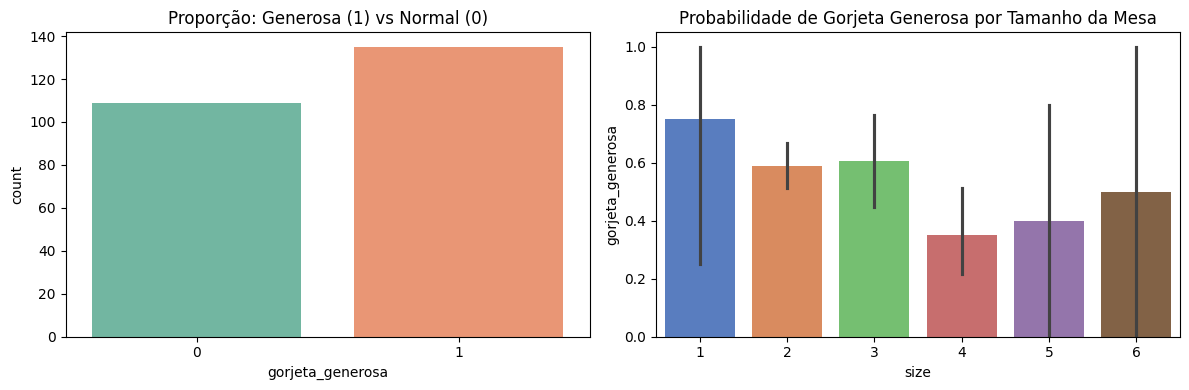

In [ ]:
# EXPLORAÇÃO VISUAL

# plt.figure(): Cria uma tela em branco (um quadro).
# figsize=(12, 4): Define a largura (12 polegadas) e a altura (4 polegadas) do quadro.
plt.figure(figsize=(12, 4))

# plt.subplot(linhas, colunas, posicao): Divide o quadro em partes.
# Aqui pedimos 1 linha, 2 colunas, e vamos desenhar na posição 1.
plt.subplot(1, 2, 1)

# sns.countplot(): Gráfico de contagem. Ele vai na coluna 'gorjeta_generosa', conta quantos 0s e 1s existem e desenha as barras.
# palette='Set2': Escolhe um conjunto de cores suaves e agradáveis.
sns.countplot(data=df, x='gorjeta_generosa', palette='Set2')
plt.title("Proporção: Generosa (1) vs Normal (0)")

# Mudando o foco do pincel para a posição 2 (o gráfico da direita).
plt.subplot(1, 2, 2)

# sns.barplot(): Gráfico de barras estatístico.
# x='size': Eixo X recebe as categorias (Tamanho da mesa: 1 pessoa, 2 pessoas, etc).
# y='gorjeta_generosa': Como essa coluna só tem 0 ou 1, o Seaborn calcula a MÉDIA automaticamente.
# Uma média de 0.30 significa que 30% daquelas mesas deram gorjetas generosas.
sns.barplot(data=df, x='size', y='gorjeta_generosa', palette='muted')
plt.title("Probabilidade de Gorjeta Generosa por Tamanho da Mesa")

# plt.tight_layout(): Ajusta os espaços automaticamente para um gráfico não invadir o espaço (texto) do outro.
plt.tight_layout()
# plt.show(): Exibe a pintura finalizada na tela.
plt.show()

##Passo 3: Tratamento de Dados (Preparando o terreno)
Modelos de Machine Learning não sabem ler textos como "Sun" (Domingo) ou "Female" (Feminino). Precisamos traduzir isso para números (0 e 1). Além disso, vamos apagar as colunas antigas de gorjeta, senão estaríamos "dando a cola da prova" para o modelo!

In [ ]:
# TRATAMENTO E PREPARAÇÃO DOS DADOS

# .drop(columns=[...]): Remove colunas específicas da tabela.
# Fazemos isso porque o valor absoluto da gorjeta daria a "cola da prova" para o modelo.
df_limpo = df.drop(columns=['tip', 'porcentagem_gorjeta'])

# pd.get_dummies(): O famoso "One-Hot Encoding".
# Ele procura qualquer coluna de texto (ex: 'sex' -> 'Male'/'Female') e a transforma em colunas numéricas binárias (0 e 1).
df_tratado = pd.get_dummies(df_limpo)

# Isolando as 10 colunas que serão as características (X - As dicas que a máquina usará).
colunas_modelo = [
    'total_bill', 'size', 'sex_Male', 'smoker_Yes',
    'day_Thur', 'day_Fri', 'day_Sat', 'day_Sun',
    'time_Lunch', 'time_Dinner'
]
X = df_tratado[colunas_modelo]

# A coluna (y) é a resposta do gabarito que a máquina tem que aprender a prever.
y = df_tratado['gorjeta_generosa']

# train_test_split(): A função de particionamento.
# test_size=0.20: Separa 20% das linhas para a prova final (Teste), e deixa 80% para o estudo (Treino).
# random_state=42: Fixa a semente de aleatoriedade. Garante que todo aluno na sala terá os mesmos 20% separados, para os resultados serem idênticos na aula.
X_treino, _, y_treino, _ = train_test_split(X, y, test_size=0.20, random_state=42)

# StandardScaler(): Instancia a ferramenta de padronização matemática.
scaler = StandardScaler()

# .fit_transform(X_treino): Dois passos em um.
# 'fit' calcula a Média e o Desvio Padrão do treino. 'transform' aplica a fórmula matemática em todos os números.
X_treino_escalonado = scaler.fit_transform(X_treino)

print("Dados históricos preparados e escalonados com sucesso!")

Dados históricos preparados e escalonados com sucesso!


## O Simulador Interativo de Cliente
Preencha as 10 variáveis abaixo com dados inventados por você. Nas próximas células, perguntaremos a cada algoritmo treinado o que ele acha que ESSE cliente fará.

In [ ]:
# SIMULADOR CLIENTE

# Mude esses valores manualmente para "criar" um cliente
valor_da_conta = 120.50
tamanho_da_mesa = 4
cliente_homem = 1
cliente_fumante = 0
dia_quinta = 0
dia_sexta = 1
dia_sabado = 0
dia_domingo = 0
horario_almoco = 0
horario_jantar = 1

# O modelo exige que os dados entrem no exato formato de uma "tabela" de 1 linha.
# O Python usa colchetes duplos [[...]] para representar isso (uma matriz de 1 linha e 10 colunas).
novo_cliente = [[valor_da_conta, tamanho_da_mesa, cliente_homem, cliente_fumante,
                 dia_quinta, dia_sexta, dia_sabado, dia_domingo,
                 horario_almoco, horario_jantar]]

# .transform(): Aplica a MESMA conversão matemática (média e desvio padrão do histórico) neste novo cliente,
# para que ele "fale o mesmo idioma matemático" que os modelos aprenderam.
novo_cliente_escalonado = scaler.transform(novo_cliente)

# Função personalizada para ler a resposta da máquina (que é um array, ex: [1] ou [0])
# e imprimir um texto amigável na tela.
def revelar_previsao(resultado):
    # resultado[0] acessa o primeiro item da lista de respostas do algoritmo.
    if resultado[0] == 1:
        print("💰 PREVISÃO: O Cliente deixará uma Gorjeta Generosa! (>15%)")
    else:
        print("📉 PREVISÃO: O Cliente deixará uma Gorjeta Comum/Baixa.")

##Modelo 1: k-NN (Vizinhos Mais Próximos)
Fase de Treinamento: O k-NN vai memorizar o mapa de clientes e procurar os 5 mais parecidos.

In [ ]:
# MODELO k-NN

# KNeighborsClassifier(n_neighbors=5): Configuração inicial do k-NN.
# n_neighbors=5 diz para a máquina procurar os 5 clientes do passado mais parecidos com o novo cliente e fazer uma votação.
knn = KNeighborsClassifier(n_neighbors=5)

# .fit(X, y): O comando universal de aprendizado. Passamos as características (X) e o gabarito (y).
knn.fit(X_treino_escalonado, y_treino)
print("Modelo k-NN treinado!")



Modelo k-NN treinado!


In [ ]:
# .predict(): O comando de prova/inferência. A máquina não vê o 'y', ela deve adivinhar a resposta baseada no 'X'.
previsao_knn = knn.predict(novo_cliente_escalonado)
print("Segundo o k-NN:")
revelar_previsao(previsao_knn)


Segundo o k-NN:
📉 PREVISÃO: O Cliente deixará uma Gorjeta Comum/Baixa.


##Modelo 2: Árvore de Decisão
Fase de Treinamento: O algoritmo vai criar um fluxograma lógico de perguntas (Sim/Não) baseado no histórico.

In [ ]:
# ÁRVORE DE DECISÃO

# DecisionTreeClassifier(): Configuração da Árvore.
# max_depth=3: Trava o crescimento da árvore em no máximo 3 níveis de profundidade (3 perguntas seguidas).
# Isso impede o 'Overfitting' (quando a árvore decora dados demais e cria regras malucas).
# random_state=42: Como existem decisões aleatórias em caso de empates ao montar a árvore, isso garante que a árvore desenhada será igual para toda a sala.
arvore = DecisionTreeClassifier(max_depth=3, random_state=42)
arvore.fit(X_treino_escalonado, y_treino)
print("Árvore de Decisão plantada e treinada!")


Árvore de Decisão plantada e treinada!


In [ ]:
# Fase de Avaliação / Inferência
previsao_arvore = arvore.predict(novo_cliente_escalonado)
print("Segundo a Árvore de Decisão:")
revelar_previsao(previsao_arvore)

Segundo a Árvore de Decisão:
💰 PREVISÃO: O Cliente deixará uma Gorjeta Generosa! (>15%)


##Modelo 3: Naive Bayes
Fase de Treinamento: O algoritmo calculará a probabilidade estatística de cada característica isolada resultar em uma boa gorjeta.

In [ ]:
# NAIVE BAYES

# GaussianNB(): Modelo baseado no Teorema de Bayes.
# Não exige parâmetros de configuração, ele apenas calcula as probabilidades condicionais usando a curva Normal (Gaussiana).
nb = GaussianNB()
nb.fit(X_treino_escalonado, y_treino)
print("Modelo Probabilístico Naive Bayes treinado!")


Modelo Probabilístico Naive Bayes treinado!


In [ ]:
# Fase de Avaliação / Inferência
previsao_nb = nb.predict(novo_cliente_escalonado)
print("Segundo o Naive Bayes:")
revelar_previsao(previsao_nb)

Segundo o Naive Bayes:
📉 PREVISÃO: O Cliente deixará uma Gorjeta Comum/Baixa.


##Modelo 4: Regressão Logística
Fase de Treinamento: Encontra a equação matemática da Curva Sigmoide que melhor separa os clientes generosos dos econômicos.

In [ ]:
# REGRESSÃO LOGÍSTICA

# LogisticRegression(): O modelo que aplica a Curva Sigmoide (matemática).
# Por padrão, ele tenta traçar a melhor curva que separa os 0s dos 1s, retornando um valor entre 0 e 1 (porcentagem de chance).
reg_log = LogisticRegression()
reg_log.fit(X_treino_escalonado, y_treino)
print("Equação da Regressão Logística ajustada e treinada!")


Equação da Regressão Logística ajustada e treinada!


In [ ]:
# Fase de Avaliação / Inferência
previsao_reg = reg_log.predict(novo_cliente_escalonado)
print("Segundo a Regressão Logística:")
revelar_previsao(previsao_reg)

Segundo a Regressão Logística:
📉 PREVISÃO: O Cliente deixará uma Gorjeta Comum/Baixa.


##Modelo 5: Random Forest (A Sabedoria das Multidões)
Fase de Treinamento: O computador vai criar e treinar 100 Árvores de Decisão diferentes simultaneamente. O resultado final será por votação da maioria.

In [ ]:
# RANDOM FOREST

# RandomForestClassifier(): O modelo de Ensemble (Sabedoria das Multidões).
# n_estimators=100: Diz para o computador criar exatamente 100 Árvores de Decisão (weak learners).
# random_state=42: Garante que os dados picotados aleatoriamente para cada árvore sejam os mesmos para todos os alunos.
floresta = RandomForestClassifier(n_estimators=100, random_state=42)
floresta.fit(X_treino_escalonado, y_treino)
print("As 100 árvores da Floresta Aleatória foram treinadas!")

As 100 árvores da Floresta Aleatória foram treinadas!


In [ ]:
# Fase de Avaliação / Inferência
previsao_floresta = floresta.predict(novo_cliente_escalonado)
print("Segundo a votação do Random Forest:")
revelar_previsao(previsao_floresta)

Segundo a votação do Random Forest:
📉 PREVISÃO: O Cliente deixará uma Gorjeta Comum/Baixa.


##Passo 4: Comparação Final de Desempenho
Agora que nossos modelos estão treinados, vamos colocá-los à prova. Vamos usar os clientes do "Futuro" (Dados de Teste que separamos no início) e verificar quantas vezes cada algoritmo acertou ou errou.

Quando um modelo erra, ele pode cometer dois tipos de falhas diferentes:

Falso Positivo: O modelo criou falsas expectativas. Ele previu que o cliente daria uma Gorjeta Generosa, mas a gorjeta foi comum/baixa.

Falso Negativo: O modelo foi pessimista. Ele previu uma gorjeta comum, mas o cliente surpreendeu e deixou uma Gorjeta Generosa.

In [ ]:
# ==========================================
# CÉLULA DE CÓDIGO 16: COMPARAÇÃO FINAL (ACERTOS E ERROS)
# ==========================================

# 1. Recuperamos as linhas que separamos lá no início (X_teste e y_teste), que representam 20% da nossa base original.
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.20, random_state=42)

# 2. Aplicamos a mesma padronização matemática, pois as máquinas só "entendem" números escalonados.
X_teste_escalonado = scaler.transform(X_teste)

# Criamos um Dicionário: Uma lista organizada que guarda os nomes e as variáveis dos 5 modelos treinados.
modelos = {
    "k-NN": knn,
    "Árvore de Decisão": arvore,
    "Naive Bayes": nb,
    "Regressão Logística": reg_log,
    "Random Forest": floresta
}

# len() lê a quantidade de clientes que estão no pacote de testes.
print(f"Total de clientes submetidos à prova: {len(y_teste)} clientes\n")
print("="*50)

# O laço 'for' vai rodar o mesmo teste estatístico para cada um dos 5 modelos automaticamente.
for nome_modelo, modelo in modelos.items():

    # A máquina faz as inferências para todos os 49 clientes de uma só vez!
    previsoes = modelo.predict(X_teste_escalonado)

    # Zerando nossos placares antes de avaliar cada algoritmo
    acertos = 0
    falsos_positivos = 0
    falsos_negativos = 0

    # A função zip() emparelha o que a máquina "chutou" (previsto) com a vida real (real).
    # O laço analisa cliente por cliente.
    for previsto, real in zip(previsoes, y_teste):
        # A máquina previu o mesmo número (0 ou 1) que consta no gabarito real?
        if previsto == real:
            acertos += 1

        # O modelo marcou 1 (Esperava Gorjeta Alta), mas a vida real era 0 (Gorjeta Baixa)?
        elif previsto == 1 and real == 0:
            falsos_positivos += 1

        # O modelo marcou 0 (Esperava Gorjeta Baixa), mas a vida real era 1 (Surpresa, Gorjeta Alta!)?
        elif previsto == 0 and real == 1:
            falsos_negativos += 1

    # Somamos os dois tipos de erros
    erros_totais = falsos_positivos + falsos_negativos

    # Exibindo o relatório impresso na tela com formatação
    print(f"--- Desempenho do {nome_modelo} ---")
    print(f"✅ Acertos Totais : {acertos}")
    print(f"❌ Erros Totais   : {erros_totais}")
    print(f"   -> Falsos Positivos (Achou que daria boa gorjeta, mas errou) : {falsos_positivos}")
    print(f"   -> Falsos Negativos (Achou que daria má gorjeta, mas errou)  : {falsos_negativos}")
    print("-" * 50)

Total de clientes submetidos à prova: 49 clientes

--- Desempenho do k-NN ---
✅ Acertos Totais : 26
❌ Erros Totais   : 23
   -> Falsos Positivos (Achou que daria boa gorjeta, mas errou) : 13
   -> Falsos Negativos (Achou que daria má gorjeta, mas errou)  : 10
--------------------------------------------------
--- Desempenho do Árvore de Decisão ---
✅ Acertos Totais : 29
❌ Erros Totais   : 20
   -> Falsos Positivos (Achou que daria boa gorjeta, mas errou) : 18
   -> Falsos Negativos (Achou que daria má gorjeta, mas errou)  : 2
--------------------------------------------------
--- Desempenho do Naive Bayes ---
✅ Acertos Totais : 32
❌ Erros Totais   : 17
   -> Falsos Positivos (Achou que daria boa gorjeta, mas errou) : 12
   -> Falsos Negativos (Achou que daria má gorjeta, mas errou)  : 5
--------------------------------------------------
--- Desempenho do Regressão Logística ---
✅ Acertos Totais : 32
❌ Erros Totais   : 17
   -> Falsos Positivos (Achou que daria boa gorjeta, mas errou) :

###Discussão Final
Observe os Falsos Positivos e Falsos Negativos acima. Dependendo do objetivo do negócio, um tipo de erro é muito mais perigoso que o outro.

Em um restaurante, um Falso Positivo causa apenas frustração no garçom.

Mas e na área da saúde? Se o modelo estiver prevendo doenças, um Falso Negativo significa mandar para casa um paciente que está doente. Nesse cenário, o Cientista de Dados deve priorizar o modelo que tem o menor número de Falsos Negativos, mesmo que a quantidade de acertos totais seja um pouco menor!